In [ ]:
# Colab setup
!apt-get update -qq
!apt-get install -y tesseract-ocr \
fonts-liberation fonts-freefont-ttf \
fonts-urw-base35 fonts-dejavu
!pip install -q pytesseract opencv-python \
python-Levenshtein tqdm matplotlib Pillow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
tesseract-ocr is already the newest version (4.1.1-2.1build1).
Suggested packages:
  fonts-texgyre
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra fonts-freefont-ttf
  fonts-urw-base35
0 upgraded, 5 newly installed, 0 to remove and 12 not upgraded.
Need to get 11.8 MB of archives.
After this operation, 28.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/u

In [ ]:
# Imports

import cv2
import numpy as np
import gradio as gr
import traceback
import pytesseract
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from Levenshtein import distance as lev_distance

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

In [ ]:

# 2. Vocabulary
# Mix of common words AND number tokens so OCR must handle digits.
WORDS = [
    "the","and","for","are","but","not","you","all","can","had",
    "her","was","one","our","out","day","get","has","him","his",
    "how","man","new","now","old","see","two","way","who","did",
    "its","let","put","say","she","too","use","able","also","back",
    "been","call","come","each","find","from","give","good","grow",
    "have","help","here","home","just","keep","know","last","left",
    "life","like","line","live","long","look","made","make","many",
    "more","most","move","much","must","name","need","next","open",
    "over","page","part","play","real","same","seem","send","show",
    "side","some","take","tell","than","them","then","they","this",
    "time","turn","very","walk","well","went","were","what","when",
    "with","word","work","year","your","about","after","again","along",
    "asked","before","being","below","between","both","came","close",
    "could","every","found","going","great","group","hands","large",
    "later","light","might","money","never","night","often","other",
    "place","point","power","right","round","small","sound","still",
    "study","their","there","these","thing","think","those","three",
    "through","under","until","watch","where","which","while","white",
    "whole","world","would","write","young","above","across","almost",
    "always","around","become","better","called","change","children",
    "during","enough","except","follow","forest","given","going",
    "ground","heard","important","inside","interest","itself","known",
    "large","later","learn","letter","longer","miles","minutes","miss",
    "nothing","number","often","order","outside","paper","picture",
    "planet","plant","pretty","problem","produce","pulled","question",
    "ready","reason","result","return","river","school","second",
    "simple","since","sister","slowly","something","sometimes","soon",
    "started","stayed","stood","story","street","suddenly","surface",
    "taken","things","thought","tonight","toward","travel","trees",
    "trying","turned","twenty","uncle","under","usually","voice",
    "walked","wanted","watched","water","without","words","worked",
]

# Number tokens mixed into text — single digits, teens, round numbers
NUMBER_TOKENS = [
    "0","1","2","3","4","5","6","7","8","9",
    "10","12","15","20","24","30","42","50","60","75","100",
    "200","365","500","1000",
]

def make_sentence(min_words: int = 5, max_words: int = 10) -> str:
    """
    Generate a synthetic sentence mixing words and occasional numbers.
    Numbers appear at ~20% token probability to reflect real documents.
    First word capitalised. No punctuation — keeps ground truth clean
    for fair CER/WER comparison (Tesseract is inconsistent with punct).
    """
    n = random.randint(min_words, max_words)
    tokens = []
    for i in range(n):
        if i > 0 and random.random() < 0.20:
            tokens.append(random.choice(NUMBER_TOKENS))
        else:
            tokens.append(random.choice(WORDS))
    tokens[0] = tokens[0].capitalize()
    return " ".join(tokens)


def make_paragraph(min_lines: int = 3, max_lines: int = 6) -> str:
    """
    Generate a multi-line paragraph. Each line is an independent
    sentence. Returns the full ground truth string with newlines.
    """
    n_lines = random.randint(min_lines, max_lines)
    return "\n".join(make_sentence() for _ in range(n_lines))

In [ ]:
#Font Discovery

FONT_DIRS = [
    "/usr/share/fonts/truetype/liberation",
    "/usr/share/fonts/truetype/freefont",
    "/usr/share/fonts/truetype/dejavu",
    "/usr/share/fonts/truetype/ubuntu",
    "/usr/share/fonts/truetype/urw-base35",
    "/usr/share/fonts/truetype",
    "/usr/share/fonts",
]
EXCLUDE_KEYWORDS = [
    "bold","italic","oblique","narrow","condensed","light","thin",
    "black","heavy","medium","semi","ext","cjk","emoji","math",
    "symbol","dingbat","webdings","wingding",
]

def find_fonts() -> list:
    found = []
    for d in FONT_DIRS:
        if not os.path.isdir(d):
            continue
        for f in Path(d).rglob("*.ttf"):
            if any(kw in f.name.lower() for kw in EXCLUDE_KEYWORDS):
                continue
            found.append(str(f))
    seen, unique = set(), []
    for f in found:
        stem = Path(f).stem.lower()
        if stem not in seen:
            seen.add(stem); unique.append(f)
    return unique

AVAILABLE_FONTS = find_fonts()
if not AVAILABLE_FONTS:
    raise RuntimeError(
        "No fonts found.\n"
        "Run: apt-get install -y fonts-liberation fonts-freefont-ttf fonts-dejavu"
    )
print(f"Fonts: {len(AVAILABLE_FONTS)} available")
for f in AVAILABLE_FONTS[:5]:
    print(f"  {Path(f).name}")



Fonts: 10 available
  LiberationSerif-Regular.ttf
  LiberationSans-Regular.ttf
  LiberationMono-Regular.ttf
  FreeSerif.ttf
  FreeMono.ttf


In [ ]:
#Paragraph Image Rendering

def render_paragraph_image(paragraph: str,
                            font_path: str,
                            font_size: int,
                            bg_mean: int = 238,
                            text_mean: int = 20) -> np.ndarray:
    """
    Render a multi-line paragraph as a grayscale numpy image.
    Each newline in paragraph becomes a new rendered line.
    """
    try:
        font = ImageFont.truetype(font_path, font_size)
    except Exception:
        font = ImageFont.load_default()

    lines = paragraph.split("\n")
    pad   = 15

    # Measure each line to determine canvas size
    dummy      = Image.new("L", (1, 1))
    dummy_draw = ImageDraw.Draw(dummy)

    line_bboxes = [dummy_draw.textbbox((0, 0), ln, font=font) for ln in lines]
    line_widths = [max(bb[2] - bb[0], 1) for bb in line_bboxes]
    line_height = max(max(bb[3] - bb[1], 1) for bb in line_bboxes)

    line_spacing = int(line_height * 1.4)   # 1.4× standard typographic ratio
    canvas_w     = max(line_widths) + 2 * pad
    canvas_h     = line_spacing * len(lines) + 2 * pad

    # Paper-texture background
    bg  = np.random.normal(bg_mean, 5, (canvas_h, canvas_w)).clip(210, 255).astype(np.uint8)
    img = Image.fromarray(bg, mode="L")
    drw = ImageDraw.Draw(img)

    text_col = int(np.clip(np.random.normal(text_mean, 4), 0, 40))

    for i, (line, bbox) in enumerate(zip(lines, line_bboxes)):
        y = pad + i * line_spacing - bbox[1]
        drw.text((pad - bbox[0], y), line, font=font, fill=text_col)

    return np.array(img)


def build_dataset(n_samples: int) -> list:
    """
    Generate n_samples (gt_string, image_np) pairs.
    Font and size randomised per sample.
    GT stored as space-separated (newlines removed) for metric use.
    """
    dataset = []
    for _ in tqdm(range(n_samples), desc="Generating paragraphs"):
        para      = make_paragraph(min_lines=3, max_lines=6)
        font_path = random.choice(AVAILABLE_FONTS)
        font_size = random.randint(20, 28)
        img       = render_paragraph_image(para, font_path, font_size)
        # GT normalised to single-space-separated for fair comparison
        gt = normalise_text(para)
        dataset.append((gt, img))
    return dataset

In [ ]:

#Text Normalisation

def normalise_text(text: str) -> str:
    """
    Normalise for metric comparison:
      1. Replace newlines and tabs with spaces
      2. Collapse multiple spaces to one
      3. Strip leading/trailing whitespace
      4. Lowercase
    Both GT and OCR output must use this before any metric call.
    """
    text = text.replace("\n", " ").replace("\t", " ")
    while "  " in text:
        text = text.replace("  ", " ")
    return text.strip().lower()


In [ ]:
#Distortion Parameters

SEVERITY_PARAMS = {
    "blur": {
        "mild":   {"ksize": (5,  5)},
        "medium": {"ksize": (9,  9)},
        "severe": {"ksize": (15, 15)},
    },
    "skew": {
        # Realistic document skew angles
        "mild":   {"angle": 2.0},
        "medium": {"angle": 5.0},
        "severe": {"angle": 10.0},
    },
    "contrast": {
        "mild":   {"alpha": 0.70, "beta": 18},
        "medium": {"alpha": 0.48, "beta": 12},
        "severe": {"alpha": 0.28, "beta":  6},
    },
}

DISTORTION_TYPES = ["blur", "skew", "contrast"]
SEVERITIES       = ["mild", "medium", "severe"]


def apply_distortion(image: np.ndarray,
                     dist_type: str,
                     severity: str) -> np.ndarray:
    p = SEVERITY_PARAMS[dist_type][severity]

    if dist_type == "blur":
        return cv2.GaussianBlur(image, p["ksize"], 0)

    elif dist_type == "skew":
        rows, cols = image.shape[:2]
        angle = p["angle"] * np.sign(np.sin(rows + cols))
        if angle == 0.0:
            angle = p["angle"]
        M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1.0)
        return cv2.warpAffine(image, M, (cols, rows),
                              borderMode=cv2.BORDER_REPLICATE)

    elif dist_type == "contrast":
        return cv2.convertScaleAbs(image, alpha=p["alpha"], beta=p["beta"])

    raise ValueError(f"Unknown distortion: {dist_type}")


def apply_combined(image: np.ndarray, severity: str) -> np.ndarray:
    for dt in DISTORTION_TYPES:
        image = apply_distortion(image, dt, severity)
    return image


In [ ]:
# Quality Metrics


def laplacian_variance(image: np.ndarray) -> float:
    """
    Sharpness proxy. Values calibrated for 32px char height images:
      clean              ≈ 400-1200
      mild blur  (5×5)  ≈ 150-350
      medium blur(9×9)  ≈ 40-120
      severe blur(15×15)≈ 8-35
    Threshold 350 fires on mild/medium/severe, not on clean.
    """
    return float(cv2.Laplacian(image, cv2.CV_64F).var())


def contrast_std(image: np.ndarray) -> float:
    return float(image.std())


def estimate_char_height(image: np.ndarray) -> int:
    """
    Estimate character height via connected component analysis.

    Why this is necessary for paragraphs:
    v6 used total image height as a proxy for character height.
    For a 5-line paragraph at 30px/line, total height ≈ 210px —
    upscaling to 96px would SHRINK the image, the opposite of intent.

    Connected components give us actual glyph heights. We filter
    to plausible character sizes (not noise, not full-line spans)
    and take the median.

    Returns estimated char height in pixels (minimum 10).
    """
    _, binary = cv2.threshold(image, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary)
    heights = []
    h_img, w_img = image.shape[:2]
    for i in range(1, n_labels):
        h = stats[i, cv2.CC_STAT_HEIGHT]
        w = stats[i, cv2.CC_STAT_WIDTH]
        # Filter: plausible character — not noise (< 4px), not full line
        if 4 < h < h_img * 0.35 and 2 < w < w_img * 0.25:
            heights.append(h)
    if not heights:
        return 20   # fallback
    return max(int(np.median(heights)), 10)


def skew_angle_projection(image: np.ndarray) -> float:
    """
    Projection profile method for multi-line text skew detection.

    Why minAreaRect fails for paragraphs:
    minAreaRect computes the minimum bounding rectangle of ALL
    foreground pixels. For a paragraph with variable line lengths,
    the last short line heavily biases the rectangle orientation.
    A paragraph with 5 full lines and 1 short last line will
    produce a wrong angle estimate.

    Projection profile method:
    For each candidate angle θ, rotate the binary image by θ and
    compute the row-wise sum (projection). When the image is
    correctly de-rotated, text lines are perfectly horizontal →
    projection has sharp peaks (high variance). At wrong angles,
    peaks smear across rows → low variance.
    The angle maximising projection variance is the correct skew.

    Range ±15°: covers all realistic document skew.
    Step 0.5°: fine enough for 1° precision, fast enough at ~61 steps.
    """
    gray = image if len(image.shape) == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h, w = binary.shape
    cx, cy = w // 2, h // 2

    best_angle, best_score = 0.0, -1.0
    for angle in np.arange(-15.0, 15.5, 0.5):
        M        = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        rotated  = cv2.warpAffine(binary, M, (w, h),
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        proj     = np.sum(rotated, axis=1).astype(np.float32)
        score    = float(proj.var())
        if score > best_score:
            best_score, best_angle = score, angle

    return best_angle


In [ ]:
# Preprocessing Primitives

def to_gray(image: np.ndarray) -> np.ndarray:
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.copy()


def upscale_by_char_height(image: np.ndarray,
                            target_char_h: int = 32) -> np.ndarray:
    """
    Scale so that character height ≈ target_char_h pixels.

    v6 scaled the total image to 96px height. This is correct for
    single words where image height ≈ character height. For paragraphs
    it is completely wrong — a 5-line paragraph is ~5× taller than
    one character, so upscaling total height to 96px shrinks the image.

    We estimate character height from connected components, compute
    the required scale factor, and resize the whole image.
    target_char_h=32px: Tesseract LSTM performs well at this size.
    """
    char_h = estimate_char_height(image)
    if char_h >= target_char_h:
        return image
    scale = target_char_h / char_h
    new_h = max(int(image.shape[0] * scale), 1)
    new_w = max(int(image.shape[1] * scale), 1)
    return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)


def fix_inversion(image: np.ndarray) -> np.ndarray:
    """
    Must be called AFTER contrast enhancement (same reasoning as v6).
    Severe contrast distortion compresses mean to ~85-95, which would
    incorrectly invert a light-background image if called on raw input.
    Threshold 85: after stretch, genuine dark-background images have
    mean < 85; light-background images have mean ~180+.
    """
    return cv2.bitwise_not(image) if image.mean() < 75 else image


def enhance_contrast_safe(image: np.ndarray) -> np.ndarray:
    """
    Percentile linear stretch (2nd-98th) — identical to v6.
    Rationale: CLAHE amplifies local texture variation which is
    problematic for paragraph images with large uniform background
    regions. Linear stretch scales the global range safely.
    """
    lo = float(np.percentile(image, 2))
    hi = float(np.percentile(image, 98))
    if hi - lo < 20:
        return image
    stretched = (image.astype(np.float32) - lo) / (hi - lo) * 255.0
    return np.clip(stretched, 0, 255).astype(np.uint8)


def unsharp_mask(image: np.ndarray,
                 sigma: float = 2.0,
                 strength: float = 2.5) -> np.ndarray:
    """Blur recovery. Must be called after any denoising."""
    blurred   = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def morphological_close(image: np.ndarray,
                         char_height: int = 32) -> np.ndarray:
    """
    Horizontal close to fill stroke gaps before binarization.

    v6 used a fixed (3,1) kernel. For paragraphs at 32px char height
    this is appropriate. But if char height varies, kernel should scale.
    kernel_w = max(3, char_height // 10) keeps it proportional while
    enforcing a minimum of 3px so it always has some effect.
    Kernel is strictly horizontal (height=1) to avoid merging lines.
    """
    kw     = max(3, char_height // 10)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, 1))
    return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)


def smart_binarize(image: np.ndarray, char_height: int = 32) -> np.ndarray:
    """
    Conditional binarization — extended for paragraph images.

    v6 used a fixed blockSize=15 for adaptive threshold.
    For paragraph images that are 3-10× taller, a 15px block is
    too small — it binarizes individual character regions rather
    than text-vs-background, producing heavily fragmented output.

    Block size should be ~2× char_height (covers roughly one line)
    and must be odd. This ensures each block contains a mix of
    text and background pixels, giving Otsu a meaningful bimodal
    histogram to threshold.
    """
    std = contrast_std(image)
    if std > 65:
        return image
    if std > 30:
        _, result = cv2.threshold(image, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return result
    # Adaptive — block size scaled to char height
    block = max(int(char_height * 2) | 1, 15)  # must be odd, minimum 15
    if block % 2 == 0:
        block += 1
    return cv2.adaptiveThreshold(image, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, block, 8)


def correct_skew(image: np.ndarray) -> np.ndarray:
    """
    Uses projection profile method (skew_angle_projection) instead of
    v6's minAreaRect. See skew_angle_projection() docstring for why.
    Threshold 1.0°: lower than v6's 2.5° because projection profile
    is more accurate for multi-line text, so we can safely act on
    smaller angles without false positives from glyph shape variation.
    """
    angle = skew_angle_projection(image)
    if abs(angle) < 1.0:
        return image
    h, w = image.shape[:2]
    M    = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


def add_padding(image: np.ndarray, pad: int = 15) -> np.ndarray:
    """Padding scaled up slightly (15 vs 12) for larger paragraph images."""
    return cv2.copyMakeBorder(image, pad, pad, pad, pad,
                              cv2.BORDER_CONSTANT, value=255)


In [ ]:
# Preprocessing Pipelines

def adaptive_preprocess(image: np.ndarray) -> np.ndarray:
    gray = to_gray(image)

    # Upscale based on character height (not total image height)
    gray = upscale_by_char_height(gray, target_char_h=32)

    # Measure quality metrics on upscaled image
    cs   = contrast_std(gray)
    lv   = laplacian_variance(gray)
    # Estimate char height on upscaled image for scale-aware ops
    ch   = estimate_char_height(gray)

    # Quality gate: if image is already clean, skip all processing.
    # lv > 350 = not blurry, cs > 38 = adequate contrast.
    # Clean images processed by the full pipeline show slight
    # degradation (v6 finding on mild blur/mild contrast) —
    # this gate eliminates that regression entirely.
    if lv > 350 and cs > 38:
        gray = fix_inversion(gray)
        gray = add_padding(gray, pad=15)
        return gray

    # Step 1: Contrast enhancement (before inversion check)
    if cs < 38:
        gray = enhance_contrast_safe(gray)

    # Step 2: Inversion check (after contrast enhancement)
    gray = fix_inversion(gray)

    # Step 3: Blur recovery (re-measure lv after contrast change)
    lv_post = laplacian_variance(gray)
    if lv_post < 350:
    # First pass: full strength
      gray = unsharp_mask(gray, sigma=2.0, strength=2.5)
      if lv_post < 40:
        # Second pass: reduced strength to avoid ringing artifacts
        gray = unsharp_mask(gray, sigma=1.5, strength=1.5)

    # Step 4: Morphological close (char-height-aware)
    gray = morphological_close(gray, char_height=ch)

    # Step 5: Binarize (char-height-aware block size)
    gray = smart_binarize(gray, char_height=ch)

    # Step 6: Deskew (projection profile)
    gray = correct_skew(gray)

    # Step 7: Padding
    gray = add_padding(gray, pad=15)
    return gray


def baseline_preprocess(image: np.ndarray) -> np.ndarray:
    """
    Minimal pipeline: upscale + inversion + padding.
    Shared between both evaluation arms so delta = adaptive steps only.
    Inversion applied so baseline isn't penalised for orientation.
    """
    gray = to_gray(image)
    gray = upscale_by_char_height(gray, target_char_h=32)
    gray = fix_inversion(gray)
    gray = add_padding(gray, pad=15)
    return gray


In [ ]:

# OCR Configuration

TESS_CONFIG = "--psm 6 --oem 3"

def run_ocr(image: np.ndarray) -> str:
    raw = pytesseract.image_to_string(image, config=TESS_CONFIG)
    return normalise_text(raw)



In [ ]:
# 11. Metrics

def cer(pred: str, gt: str) -> float:
    """Character Error Rate. Both strings should be normalised first."""
    return lev_distance(pred, gt) / max(len(gt), 1)


def wer(pred: str, gt: str) -> float:
    """
    Word Error Rate = (S + D + I) / N
    where S=substitutions, D=deletions, I=insertions at word level,
    N=number of words in reference (GT).

    Uses DP for word-token Levenshtein — not character-level distance
    on joined strings, which would mis-count word boundary errors.
    """
    pred_w = pred.split()
    gt_w   = gt.split()
    if not gt_w:
        return 0.0

    # DP table: d[i][j] = word edit distance between gt_w[:i], pred_w[:j]
    n, m = len(gt_w), len(pred_w)
    d    = np.zeros((n + 1, m + 1), dtype=np.int32)
    d[:, 0] = np.arange(n + 1)
    d[0, :] = np.arange(m + 1)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if gt_w[i-1] == pred_w[j-1]:
                d[i, j] = d[i-1, j-1]
            else:
                d[i, j] = 1 + min(d[i-1, j],      # deletion
                                   d[i, j-1],      # insertion
                                   d[i-1, j-1])    # substitution
    return d[n, m] / n



In [ ]:
# Sanity Check
# Pass criterion: CER < 0.08 on clean images.

def sanity_check(dataset: list, n: int = 20) -> tuple:
    print("\nSanity check on clean (undistorted) images...")
    sample    = random.sample(dataset, min(n, len(dataset)))
    cer_list  = []
    wer_list  = []
    for gt, img in tqdm(sample, desc="  Clean"):
        pred = run_ocr(baseline_preprocess(img))
        cer_list.append(cer(pred, gt))
        wer_list.append(wer(pred, gt))
    mean_cer = np.mean(cer_list)
    mean_wer = np.mean(wer_list)
    print(f"  Clean CER : {mean_cer:.4f}")
    print(f"  Clean WER : {mean_wer:.4f}")
    if mean_cer > 0.08:
        print("  WARNING: Clean CER > 0.08. Check font/PSM config.")
    else:
        print("  ✓ Baseline acceptable — proceeding.")
    return mean_cer, mean_wer


In [ ]:
# Evaluation

N_GENERATE  = 300
SAMPLE_SIZE = 150

print(f"\nGenerating {N_GENERATE} paragraph images...")
dataset = build_dataset(N_GENERATE)

clean_cer, clean_wer = sanity_check(dataset)

eval_set = random.sample(dataset, min(SAMPLE_SIZE, len(dataset)))

# results[dist_type][severity] → dict of metric lists
def new_bucket():
    return {"base_cer": [], "pre_cer": [],
            "base_wer": [], "pre_wer": []}

results  = defaultdict(lambda: defaultdict(new_bucket))
combined = defaultdict(new_bucket)

total = len(DISTORTION_TYPES) * len(SEVERITIES) + len(SEVERITIES)
print(f"\nEvaluating {SAMPLE_SIZE} paragraphs × {total} conditions × 2 pipelines...")

for gt, img in tqdm(eval_set, desc="Evaluating"):

    for dt in DISTORTION_TYPES:
        for sv in SEVERITIES:
            dist      = apply_distortion(img.copy(), dt, sv)
            pred_base = run_ocr(baseline_preprocess(dist))
            pred_pre  = run_ocr(adaptive_preprocess(dist))

            r = results[dt][sv]
            r["base_cer"].append(cer(pred_base, gt))
            r["pre_cer"].append(cer(pred_pre,   gt))
            r["base_wer"].append(wer(pred_base, gt))
            r["pre_wer"].append(wer(pred_pre,   gt))

    for sv in SEVERITIES:
        dist_c    = apply_combined(img.copy(), sv)
        pred_base = run_ocr(baseline_preprocess(dist_c))
        pred_pre  = run_ocr(adaptive_preprocess(dist_c))

        c = combined[sv]
        c["base_cer"].append(cer(pred_base, gt))
        c["pre_cer"].append(cer(pred_pre,   gt))
        c["base_wer"].append(wer(pred_base, gt))
        c["pre_wer"].append(wer(pred_pre,   gt))




Generating 300 paragraph images...


Generating paragraphs: 100%|██████████| 300/300 [00:04<00:00, 60.43it/s]



Sanity check on clean (undistorted) images...


  Clean: 100%|██████████| 20/20 [00:16<00:00,  1.22it/s]


  Clean CER : 0.0021
  Clean WER : 0.0110
  ✓ Baseline acceptable — proceeding.

Evaluating 150 paragraphs × 12 conditions × 2 pipelines...


Evaluating: 100%|██████████| 150/150 [49:03<00:00, 19.62s/it]


In [ ]:
#Results Table

SEP  = "─" * 90
SEP2 = "═" * 90

def m(val, metric="cer"):
    """Marker: ▼ = lower is better (CER/WER), ▲ = higher is better."""
    thresh = 0.02
    if metric in ("cer", "wer"):
        return "▼" if val < -thresh else ("▲" if val > thresh else "≈")
    return "▲" if val > thresh else ("▼" if val < -thresh else "≈")

def fmt_row(label, bc, pc, bw, pw):
    dc, dw = pc - bc, pw - bw
    return (
        f"  {label:<12}  "
        f"CER {bc:.4f}→{pc:.4f} {dc:+.4f}{m(dc,'cer')}  │  "
        f"WER {bw:.4f}→{pw:.4f} {dw:+.4f}{m(dw,'wer')}"
    )

all_dc, all_dw = [], []

print(f"\n{SEP2}")
print(f"  STRATIFIED RESULTS v7 — Paragraph OCR")
print(f"  Clean baseline  CER={clean_cer:.4f}  WER={clean_wer:.4f}")
print(f"  (▼ = lower = improvement for CER and WER)")
print(SEP2)

for dt in DISTORTION_TYPES:
    print(f"\n  ▌ {dt.upper()}")
    print(f"  {SEP}")
    for sv in SEVERITIES:
        r  = results[dt][sv]
        bc = np.mean(r["base_cer"]); pc = np.mean(r["pre_cer"])
        bw = np.mean(r["base_wer"]); pw = np.mean(r["pre_wer"])
        print(fmt_row(sv, bc, pc, bw, pw))
        all_dc.append(pc - bc); all_dw.append(pw - bw)

print(f"\n  ▌ COMBINED (blur + skew + contrast)")
print(f"  {SEP}")
for sv in SEVERITIES:
    c  = combined[sv]
    bc = np.mean(c["base_cer"]); pc = np.mean(c["pre_cer"])
    bw = np.mean(c["base_wer"]); pw = np.mean(c["pre_wer"])
    print(fmt_row(sv, bc, pc, bw, pw))
    all_dc.append(pc - bc); all_dw.append(pw - bw)

print(f"\n{SEP2}")
print(f"  SUMMARY AT SEVERE LEVEL")
print(SEP2)
print(f"  {'Distortion':<14} {'Base CER':>9} {'Pre CER':>9} {'Δ CER':>8} "
      f"{'Base WER':>9} {'Pre WER':>9} {'Δ WER':>8} {'CER%':>7}")
print(f"  {SEP}")

for dt in DISTORTION_TYPES:
    r   = results[dt]["severe"]
    bc  = np.mean(r["base_cer"]); pc = np.mean(r["pre_cer"])
    bw  = np.mean(r["base_wer"]); pw = np.mean(r["pre_wer"])
    pct = (bc - pc) / bc * 100 if bc > 0 else 0
    print(f"  {dt:<14} {bc:>9.4f} {pc:>9.4f} {pc-bc:>+8.4f} "
          f"{bw:>9.4f} {pw:>9.4f} {pw-bw:>+8.4f} {pct:>6.1f}%")

c   = combined["severe"]
bc  = np.mean(c["base_cer"]); pc = np.mean(c["pre_cer"])
bw  = np.mean(c["base_wer"]); pw = np.mean(c["pre_wer"])
pct = (bc - pc) / bc * 100 if bc > 0 else 0
print(f"  {'combined':<14} {bc:>9.4f} {pc:>9.4f} {pc-bc:>+8.4f} "
      f"{bw:>9.4f} {pw:>9.4f} {pw-bw:>+8.4f} {pct:>6.1f}%")

print(f"\n  Mean Δ CER across all conditions: {np.mean(all_dc):+.4f}")
print(f"  Mean Δ WER across all conditions: {np.mean(all_dw):+.4f}")



══════════════════════════════════════════════════════════════════════════════════════════
  STRATIFIED RESULTS v7 — Paragraph OCR
  Clean baseline  CER=0.0021  WER=0.0110
  (▼ = lower = improvement for CER and WER)
══════════════════════════════════════════════════════════════════════════════════════════

  ▌ BLUR
  ──────────────────────────────────────────────────────────────────────────────────────────
  mild          CER 0.0019→0.0018 -0.0001≈  │  WER 0.0074→0.0078 +0.0003≈
  medium        CER 0.0123→0.0040 -0.0083≈  │  WER 0.0314→0.0154 -0.0160≈
  severe        CER 0.1961→0.1531 -0.0429▼  │  WER 0.4465→0.2366 -0.2099▼

  ▌ SKEW
  ──────────────────────────────────────────────────────────────────────────────────────────
  mild          CER 0.0035→0.0022 -0.0013≈  │  WER 0.0146→0.0089 -0.0057≈
  medium        CER 0.0300→0.0311 +0.0011≈  │  WER 0.0842→0.0634 -0.0208▼
  severe        CER 0.1551→0.1221 -0.0329▼  │  WER 0.3730→0.1998 -0.1733▼

  ▌ CONTRAST
  ──────────────────────────

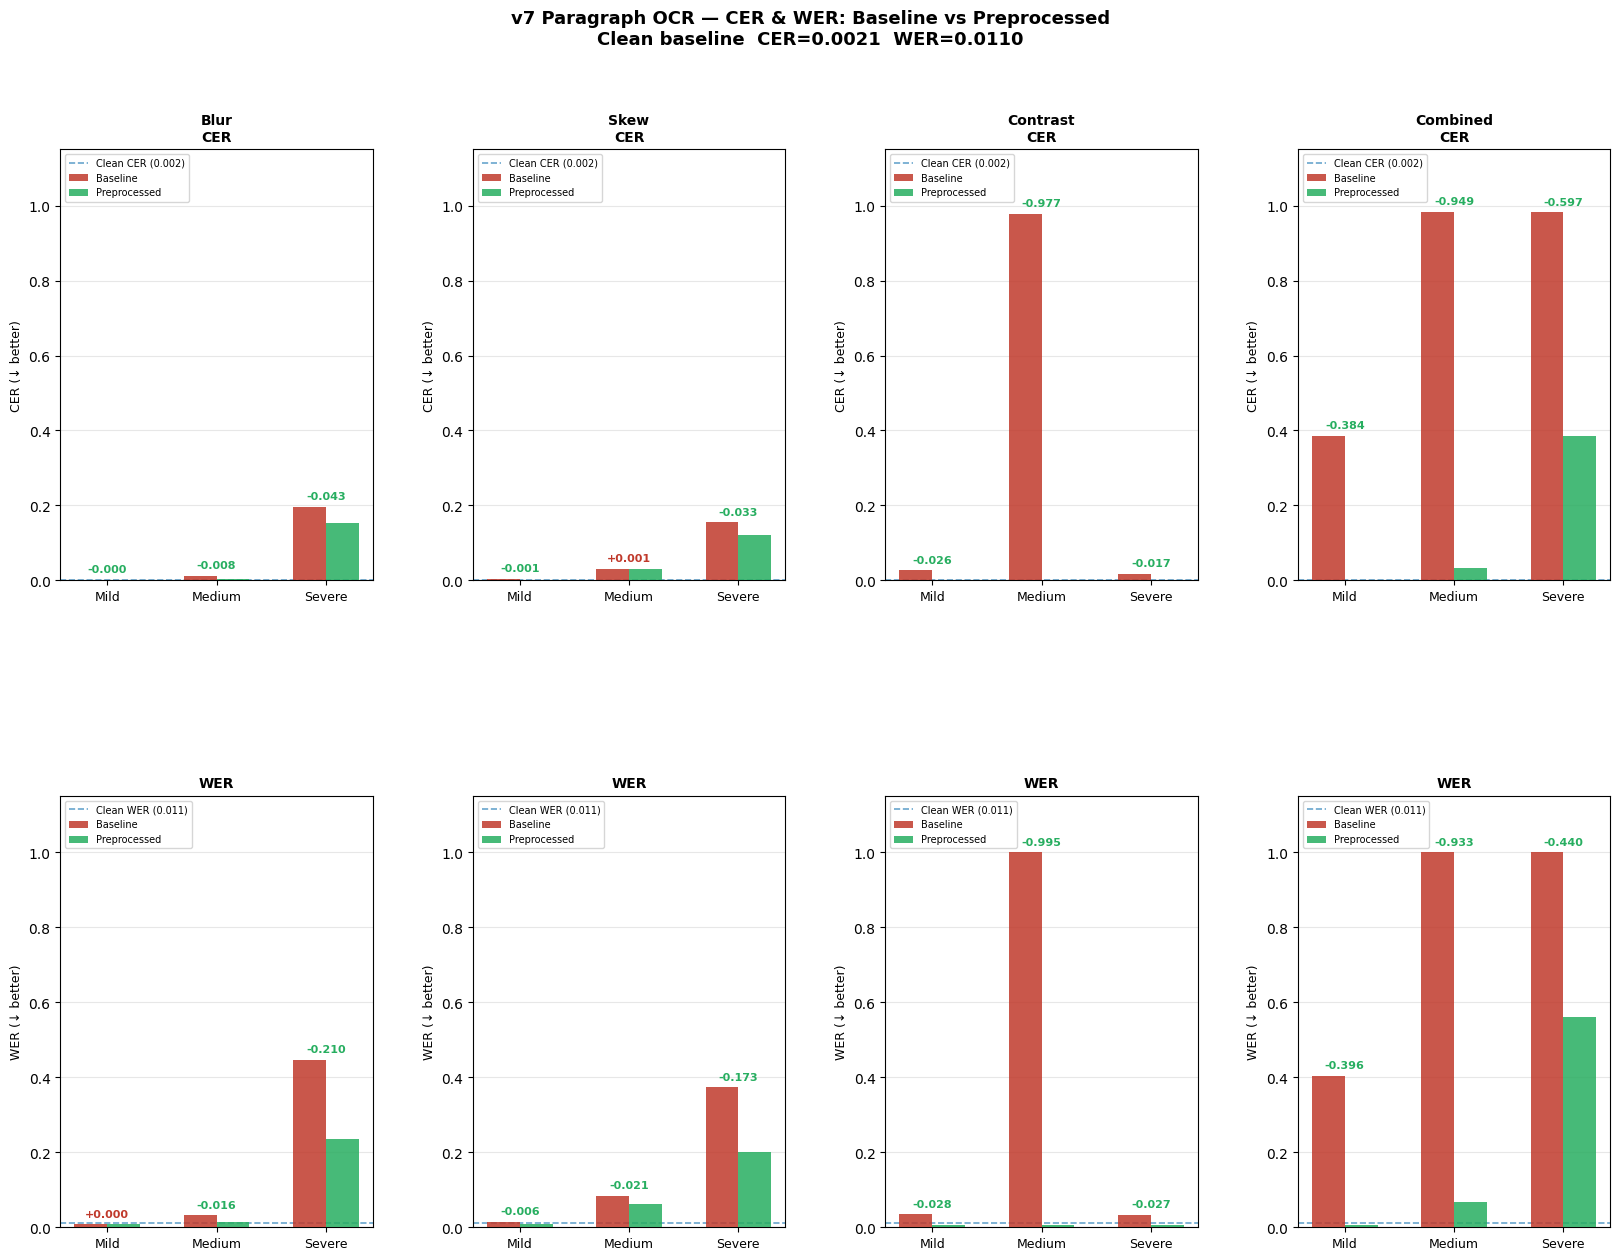

Saved: /content/v7_metrics_bars.png


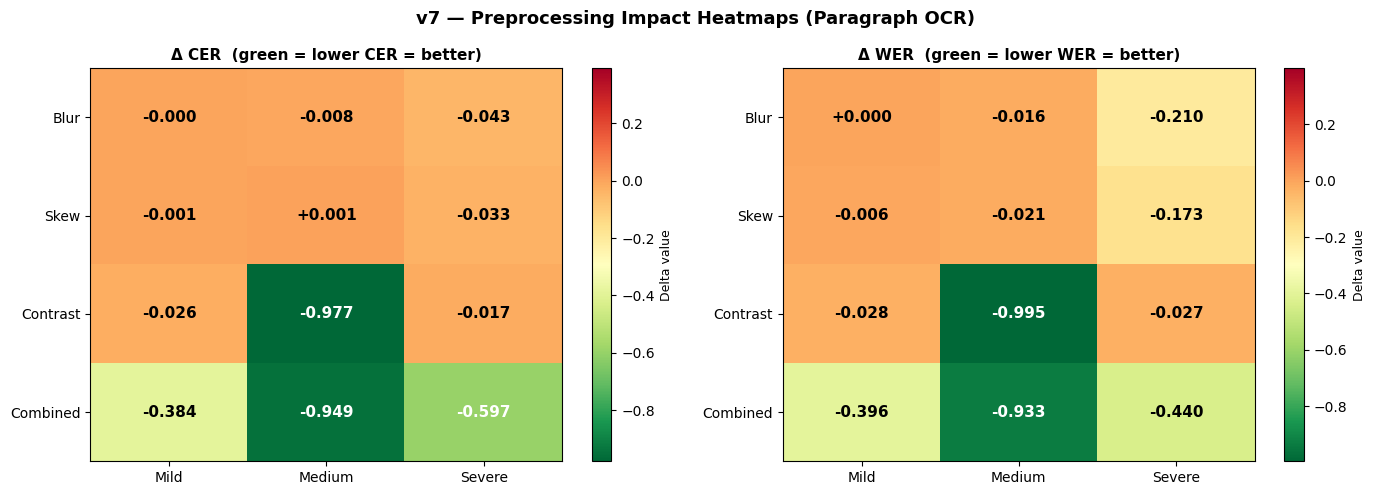

Saved: /content/v7_heatmaps.png


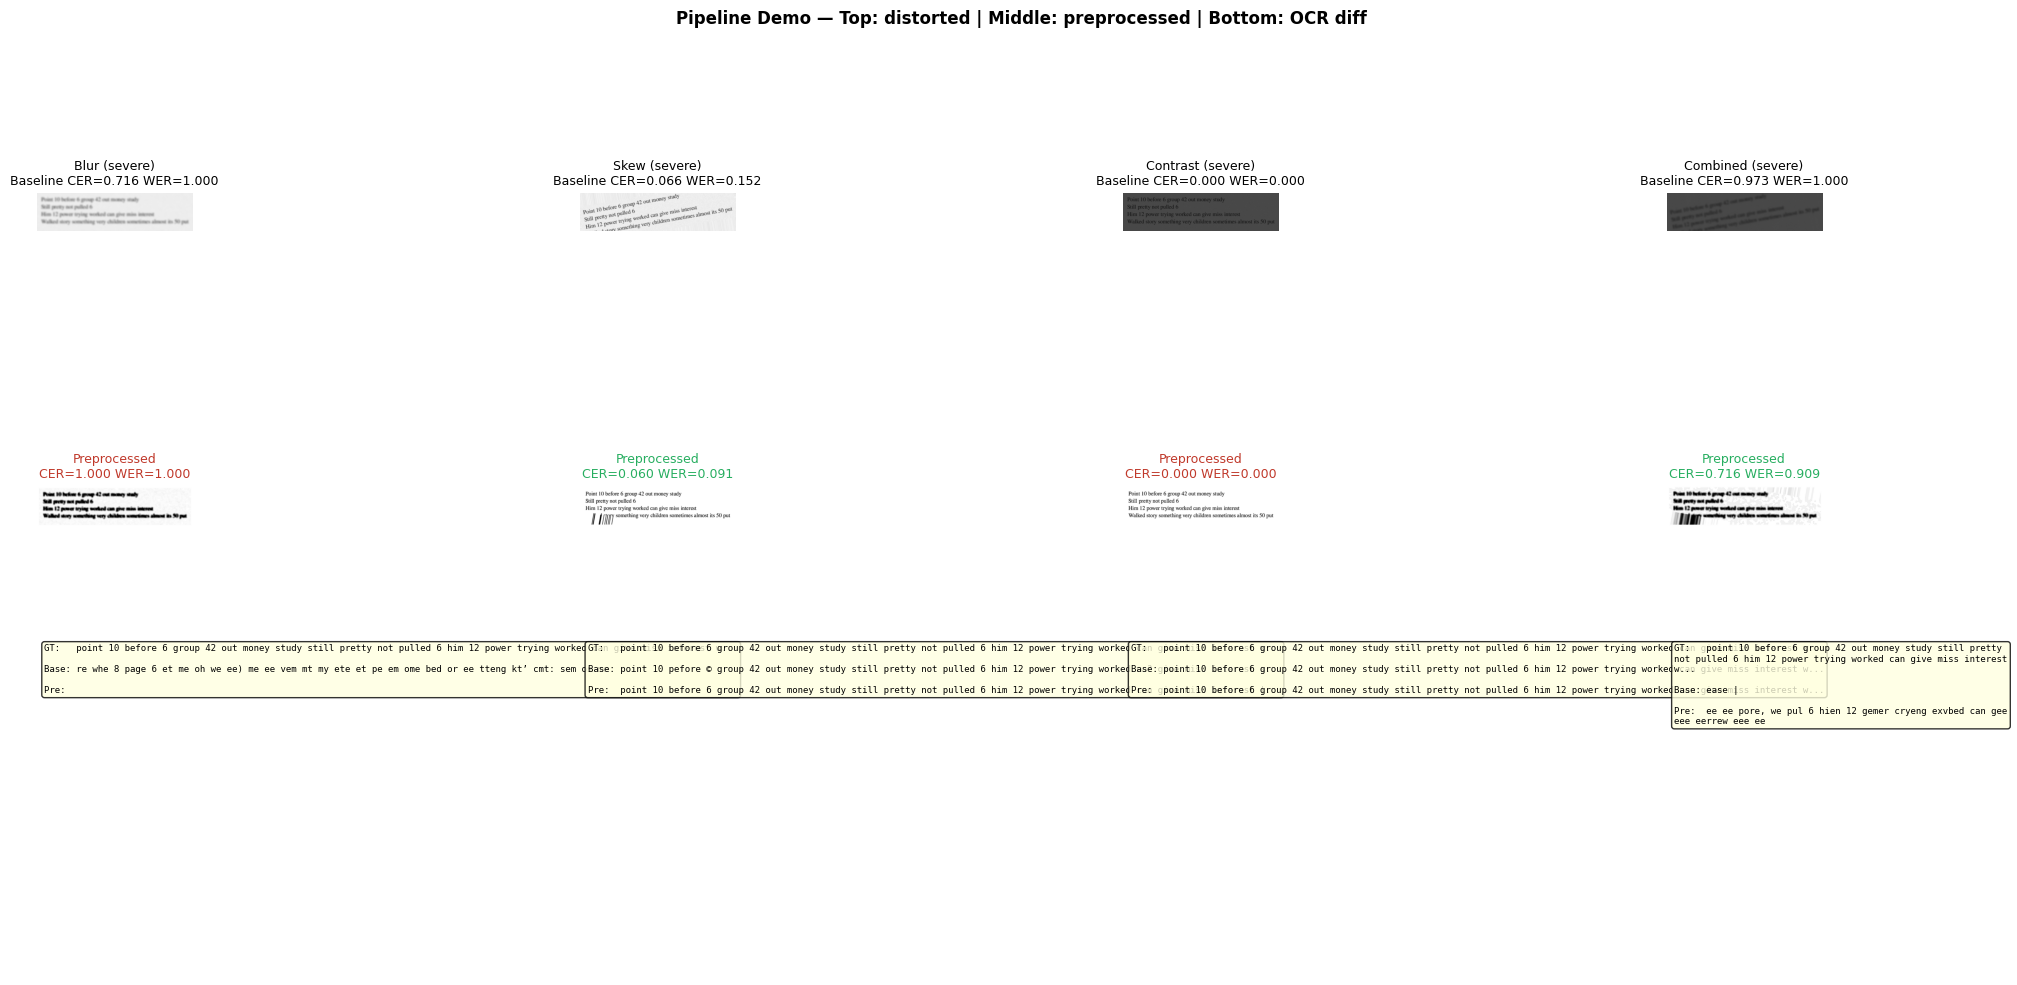

Saved: /content/v7_pipeline_demo.png

All done.


In [ ]:
# Visualisation

COLOR_BASE  = "#C0392B"
COLOR_PRE   = "#27AE60"
COLOR_CLEAN = "#2980B9"
SEV_LABELS  = [s.capitalize() for s in SEVERITIES]
BAR_W       = 0.30

# ── Fig 1: Grouped bar charts ────────────────────────────────
fig  = plt.figure(figsize=(20, 14))
gs   = gridspec.GridSpec(2, 4, figure=fig, hspace=0.50, wspace=0.32)
fig.suptitle(
    f"v7 Paragraph OCR — CER & WER: Baseline vs Preprocessed\n"
    f"Clean baseline  CER={clean_cer:.4f}  WER={clean_wer:.4f}",
    fontsize=13, fontweight="bold"
)

plot_defs = [
    (0, 0, "blur"),   (0, 1, "skew"),
    (0, 2, "contrast"),(0, 3, "combined"),
]

for row, col, dt in plot_defs:
    for metric_row, (metric, ylabel, ykey_b, ykey_p) in enumerate([
        ("CER", "CER (↓ better)", "base_cer", "pre_cer"),
        ("WER", "WER (↓ better)", "base_wer", "pre_wer"),
    ]):
        ax = fig.add_subplot(gs[metric_row, col])
        x  = np.arange(len(SEVERITIES))

        if dt == "combined":
            base_v = [np.mean(combined[s][ykey_b]) for s in SEVERITIES]
            pre_v  = [np.mean(combined[s][ykey_p]) for s in SEVERITIES]
        else:
            base_v = [np.mean(results[dt][s][ykey_b]) for s in SEVERITIES]
            pre_v  = [np.mean(results[dt][s][ykey_p]) for s in SEVERITIES]

        ax.bar(x - BAR_W/2, base_v, BAR_W,
               label="Baseline",     color=COLOR_BASE, alpha=0.85, zorder=3)
        ax.bar(x + BAR_W/2, pre_v,  BAR_W,
               label="Preprocessed", color=COLOR_PRE,  alpha=0.85, zorder=3)

        ref = clean_cer if metric == "CER" else clean_wer
        ax.axhline(ref, color=COLOR_CLEAN, linestyle="--",
                   linewidth=1.2, alpha=0.7,
                   label=f"Clean {metric} ({ref:.3f})")

        for xi, (bv, pv) in enumerate(zip(base_v, pre_v)):
            delta  = pv - bv
            colour = COLOR_PRE if delta < 0 else COLOR_BASE
            ax.text(xi, max(bv, pv) + 0.02, f"{delta:+.3f}",
                    ha="center", fontsize=8, color=colour, fontweight="bold")

        title = (dt.capitalize() if dt != "combined" else "Combined") \
                if metric_row == 0 else ""
        ax.set_title(f"{title}\n{metric}" if title else metric,
                     fontsize=10, fontweight="bold")
        ax.set_xticks(x); ax.set_xticklabels(SEV_LABELS, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(axis="y", alpha=0.3, zorder=0)

plt.savefig("/content/v7_metrics_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v7_metrics_bars.png")

# ── Fig 2: Dual heatmap (Δ CER and Δ WER) ───────────────────
rows_labels = DISTORTION_TYPES + ["combined"]
d_cer = np.zeros((len(rows_labels), len(SEVERITIES)))
d_wer = np.zeros((len(rows_labels), len(SEVERITIES)))

for ri, dt in enumerate(DISTORTION_TYPES):
    for ci, sv in enumerate(SEVERITIES):
        r = results[dt][sv]
        d_cer[ri, ci] = np.mean(r["pre_cer"]) - np.mean(r["base_cer"])
        d_wer[ri, ci] = np.mean(r["pre_wer"]) - np.mean(r["base_wer"])
for ci, sv in enumerate(SEVERITIES):
    c = combined[sv]
    d_cer[-1, ci] = np.mean(c["pre_cer"]) - np.mean(c["base_cer"])
    d_wer[-1, ci] = np.mean(c["pre_wer"]) - np.mean(c["base_wer"])

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("v7 — Preprocessing Impact Heatmaps (Paragraph OCR)",
              fontsize=13, fontweight="bold")

for ax, mat, title, cmap in [
    (ax1, d_cer, "Δ CER  (green = lower CER = better)", "RdYlGn_r"),
    (ax2, d_wer, "Δ WER  (green = lower WER = better)", "RdYlGn_r"),
]:
    lim = max(abs(mat).max(), 0.05)
    im  = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=-lim, vmax=lim*0.4)
    plt.colorbar(im, ax=ax).set_label("Delta value", fontsize=9)
    ax.set_xticks(range(len(SEVERITIES)))
    ax.set_xticklabels(SEV_LABELS, fontsize=10)
    ax.set_yticks(range(len(rows_labels)))
    ax.set_yticklabels([r.capitalize() for r in rows_labels], fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for ri in range(len(rows_labels)):
        for ci in range(len(SEVERITIES)):
            val = mat[ri, ci]
            ax.text(ci, ri, f"{val:+.3f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if abs(val) > lim * 0.6 else "black")

plt.tight_layout()
plt.savefig("/content/v7_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v7_heatmaps.png")

# ── Fig 3: Visual pipeline demo ──────────────────────────────
demo_gt, demo_img = eval_set[0]

fig3, axes3 = plt.subplots(3, 4, figsize=(20, 10))
fig3.suptitle(
    "Pipeline Demo — Top: distorted | Middle: preprocessed | Bottom: OCR diff",
    fontsize=12, fontweight="bold"
)

demo_conds = ["blur", "skew", "contrast", "combined"]

for col, cond in enumerate(demo_conds):
    sev       = "severe"
    dist_img  = (apply_combined(demo_img.copy(), sev)
                 if cond == "combined"
                 else apply_distortion(demo_img.copy(), cond, sev))
    pre_img   = adaptive_preprocess(dist_img)
    pred_base = run_ocr(baseline_preprocess(dist_img))
    pred_pre  = run_ocr(pre_img)

    bc = cer(pred_base, demo_gt)
    pc = cer(pred_pre,  demo_gt)
    bw = wer(pred_base, demo_gt)
    pw = wer(pred_pre,  demo_gt)

    # Row 0: distorted image
    axes3[0][col].imshow(dist_img, cmap="gray", vmin=0, vmax=255)
    axes3[0][col].set_title(
        f"{cond.capitalize()} (severe)\nBaseline CER={bc:.3f} WER={bw:.3f}",
        fontsize=9)
    axes3[0][col].axis("off")

    # Row 1: preprocessed image
    axes3[1][col].imshow(pre_img, cmap="gray", vmin=0, vmax=255)
    improved = pc < bc
    axes3[1][col].set_title(
        f"Preprocessed\nCER={pc:.3f} WER={pw:.3f}",
        fontsize=9,
        color=COLOR_PRE if improved else COLOR_BASE)
    axes3[1][col].axis("off")

    # Row 2: text comparison
    axes3[2][col].axis("off")
    gt_short   = demo_gt[:120] + ("..." if len(demo_gt) > 120 else "")
    base_short = pred_base[:120] + ("..." if len(pred_base) > 120 else "")
    pre_short  = pred_pre[:120]  + ("..." if len(pred_pre)  > 120 else "")
    axes3[2][col].text(
        0.05, 0.95,
        f"GT:   {gt_short}\n\n"
        f"Base: {base_short}\n\n"
        f"Pre:  {pre_short}",
        transform=axes3[2][col].transAxes,
        fontsize=6.5, va="top", fontfamily="monospace",
        wrap=True,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8)
    )

plt.tight_layout()
plt.savefig("/content/v7_pipeline_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v7_pipeline_demo.png")
print("\nAll done.")

In [ ]:

def process_image(img, distortion_type, severity):
    try:
        # Handle both numpy array and PIL input from Gradio
        if isinstance(img, np.ndarray):
            if len(img.shape) == 3:
                img_np = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            else:
                img_np = img
        else:
            img_np = np.array(img.convert('L'))

        # ← THIS was the bug: "combined" must call apply_combined
        if distortion_type == "combined":
            distorted = apply_combined(img_np.copy(), severity)
        else:
            distorted = apply_distortion(img_np.copy(), distortion_type, severity)

        preprocessed  = adaptive_preprocess(distorted)
        base_text     = run_ocr(baseline_preprocess(distorted))
        pre_text      = run_ocr(preprocessed)

        return (
            Image.fromarray(distorted),
            Image.fromarray(preprocessed),
            base_text,
            pre_text
        )

    except Exception as e:
        # Print full traceback to Colab console so you can see real error
        traceback.print_exc()
        blank = Image.fromarray(np.ones((100, 300), dtype=np.uint8) * 200)
        return blank, blank, f"ERROR: {str(e)}", f"ERROR: {str(e)}"


demo = gr.Interface(
    fn=process_image,
    inputs=[
        gr.Image(label="Upload document image"),   # no type="pil" — let Gradio decide
        gr.Dropdown(
            choices=["blur", "skew", "contrast", "combined"],
            value="blur",
            label="distortion_type"
        ),
        gr.Dropdown(
            choices=["mild", "medium", "severe"],
            value="mild",
            label="severity"
        )
    ],
    outputs=[
        gr.Image(label="Distorted"),
        gr.Image(label="Preprocessed"),
        gr.Textbox(label="Baseline OCR"),
        gr.Textbox(label="Pipeline OCR")
    ],
    title="OCR Preprocessing Pipeline Demo",
    description="Upload a document image, apply a distortion, and compare Baseline vs Preprocessed OCR output."
)

demo.launch(debug=True)   # debug=True prints errors to Colab console

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9703ca931b4e0001dd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

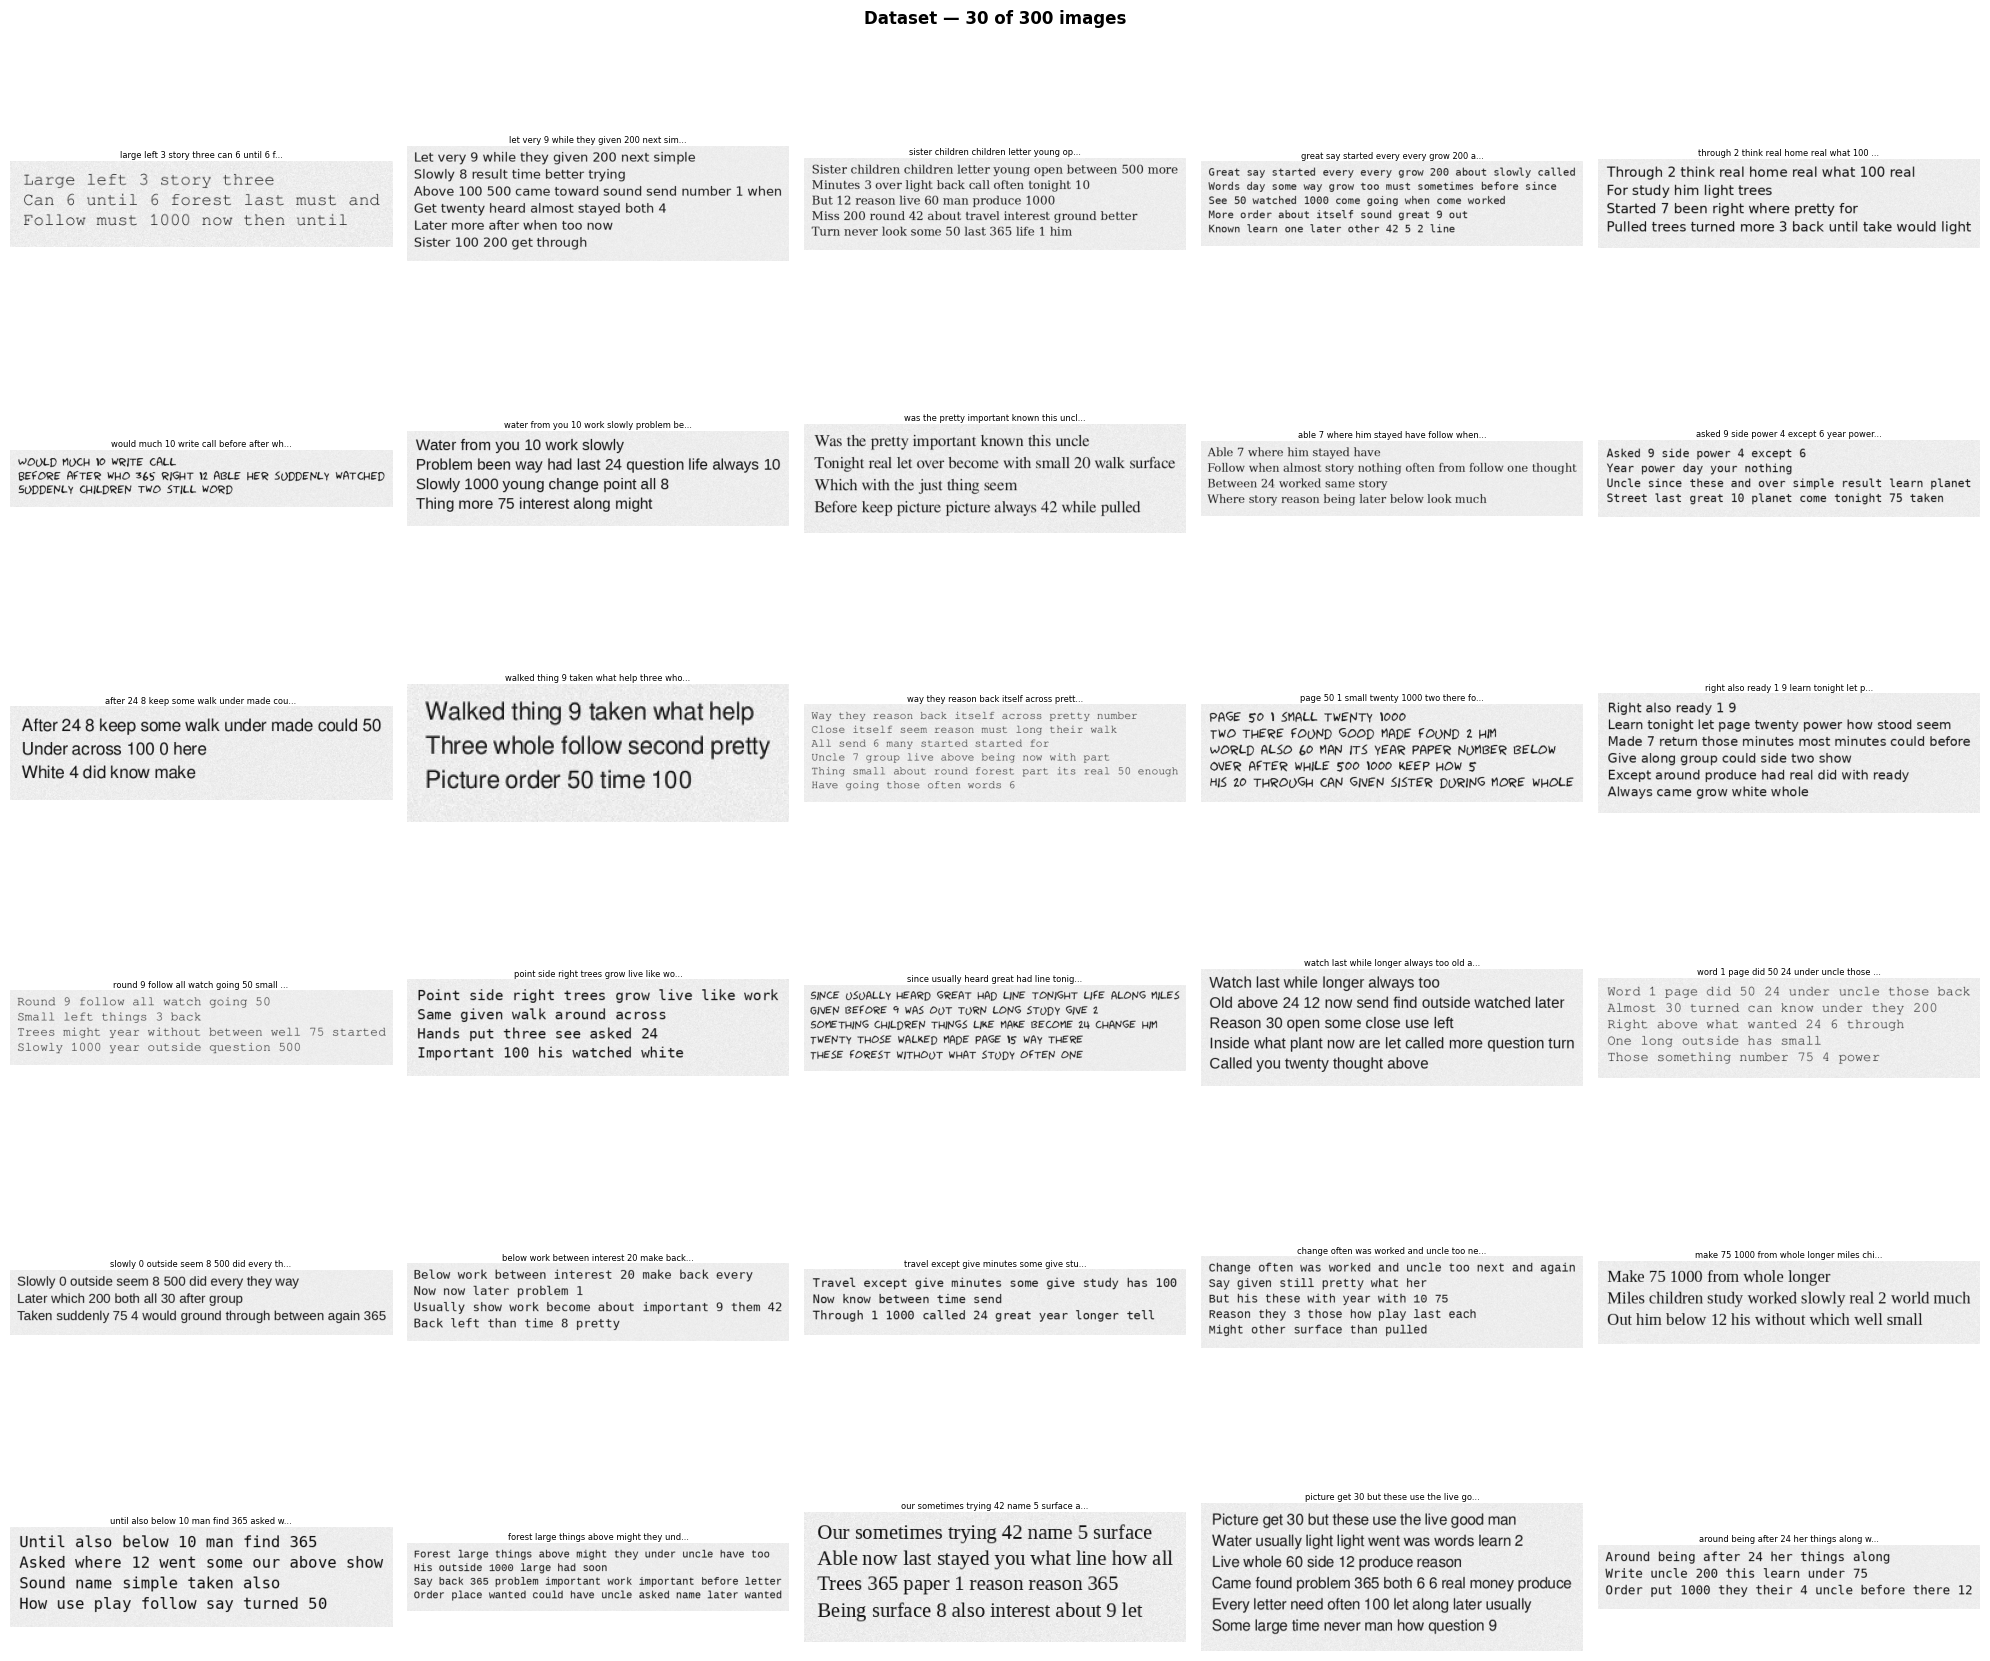

In [ ]:
#Showing the generated dataset images for verification
def show_dataset_grid(dataset, n_show=30, cols=5, figsize=(20, None)):
    """
    Display a grid of dataset images with their GT text.
    dataset: list of (gt_string, image_np) pairs
    n_show:  how many to display (don't try all 300 at once — Colab will crash)
    """
    n_show  = min(n_show, len(dataset))
    rows    = (n_show + cols - 1) // cols
    fh      = figsize[1] or rows * 3

    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], fh))
    axes = axes.flatten()

    for i in range(n_show):
        gt, img = dataset[i]
        axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
        # Show first 40 chars of GT so it fits under image
        axes[i].set_title(gt[:40] + "...", fontsize=6, pad=2)
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Dataset — {n_show} of {len(dataset)} images",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Show 30 at a time
show_dataset_grid(dataset, n_show=30, cols=5)